# 02 - LeNet y VGG-11

Entrenamiento de las cuatro variantes desde cero y experimento controlado de Batch Normalization.

In [1]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from utils import resolve_data_dir

DATA_DIR = resolve_data_dir(ROOT / "data" / "dataset")
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def run_train(*args):
    cmd = [sys.executable, str(ROOT / "src" / "train.py"), *map(str, args)]
    print(" ".join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)


COMMON_ARGS = ["--data-dir", DATA_DIR, "--results-dir", RESULTS_DIR, "--num-workers", 0]
LIMIT_SAMPLES = None  # Usa 256 solo para una prueba corta; dejalo en None para resultados finales.
if LIMIT_SAMPLES is not None:
    COMMON_ARGS += ["--limit-samples", LIMIT_SAMPLES]

ROOT, DATA_DIR, RESULTS_DIR

(WindowsPath('C:/Escritorio/PC/PC/dl-semana6-Pastor_Tomas'),
 WindowsPath('C:/Escritorio/PC/PC/dl-semana6-Pastor_Tomas/data/dataset'),
 WindowsPath('C:/Escritorio/PC/PC/dl-semana6-Pastor_Tomas/results'))

## Tarea 1: arquitecturas desde cero

Se comparan LeNet-5 adaptado, LeNet-5+BN, VGG-11 simplificado y VGG-11 simplificado+BN. Todas reciben imagenes `64x64x3`, usan el mismo split, optimizador y preprocesamiento.

In [2]:
from models import FROM_SCRATCH_MODELS, build_model, count_parameters

param_table = []
for spec in FROM_SCRATCH_MODELS:
    model = build_model(spec.name, num_classes=4, pretrained=False)
    param_table.append({
        "model": spec.name,
        "display_name": spec.display_name,
        "parameters": count_parameters(model),
        "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
    })
pd.DataFrame(param_table)

,model,display_name,parameters,trainable_parameters
0,lenet,LeNet,337976,337976
1,lenet_bn,LeNet+BN,338020,338020
2,vgg11,VGG-11 simplificado,3095748,3095748
3,vgg11_bn,VGG-11 simplificado+BN,3098500,3098500


In [3]:
EPOCHS_SCRATCH = 10

run_train(
    "--mode", "scratch",
    "--epochs", EPOCHS_SCRATCH,
    "--batch-size", 64,
    "--lr", 0.001,
    *COMMON_ARGS,
)

c:\Users\magic\AppData\Local\Programs\Python\Python311\python.exe C:\Escritorio\PC\PC\dl-semana6-Pastor_Tomas\src\train.py --mode scratch --epochs 10 --batch-size 64 --lr 0.001 --data-dir C:\Escritorio\PC\PC\dl-semana6-Pastor_Tomas\data\dataset --results-dir C:\Escritorio\PC\PC\dl-semana6-Pastor_Tomas\results --num-workers 0


In [4]:
summary = pd.read_csv(RESULTS_DIR / "tables" / "summary.csv")
task1_models = ["lenet", "lenet_bn", "vgg11", "vgg11_bn"]
columns = [
    "model", "parameters", "mean_epoch_time_sec", "best_val_accuracy",
    "test_accuracy", "epochs_to_80_val_accuracy", "lr",
]
summary[summary["model"].isin(task1_models)][columns].sort_values("model")

,model,parameters,mean_epoch_time_sec,best_val_accuracy,test_accuracy,epochs_to_80_val_accuracy,lr
0,lenet,337976,30.472509,0.831212,0.667471,9.0,0.001
1,lenet_bn,338020,31.479388,0.807770,0.602734,8.0,0.001
2,vgg11,3095748,37.245658,0.259210,0.249296,NaN,0.001
3,vgg11_bn,3098500,31.177647,0.833891,0.716526,10.0,0.001


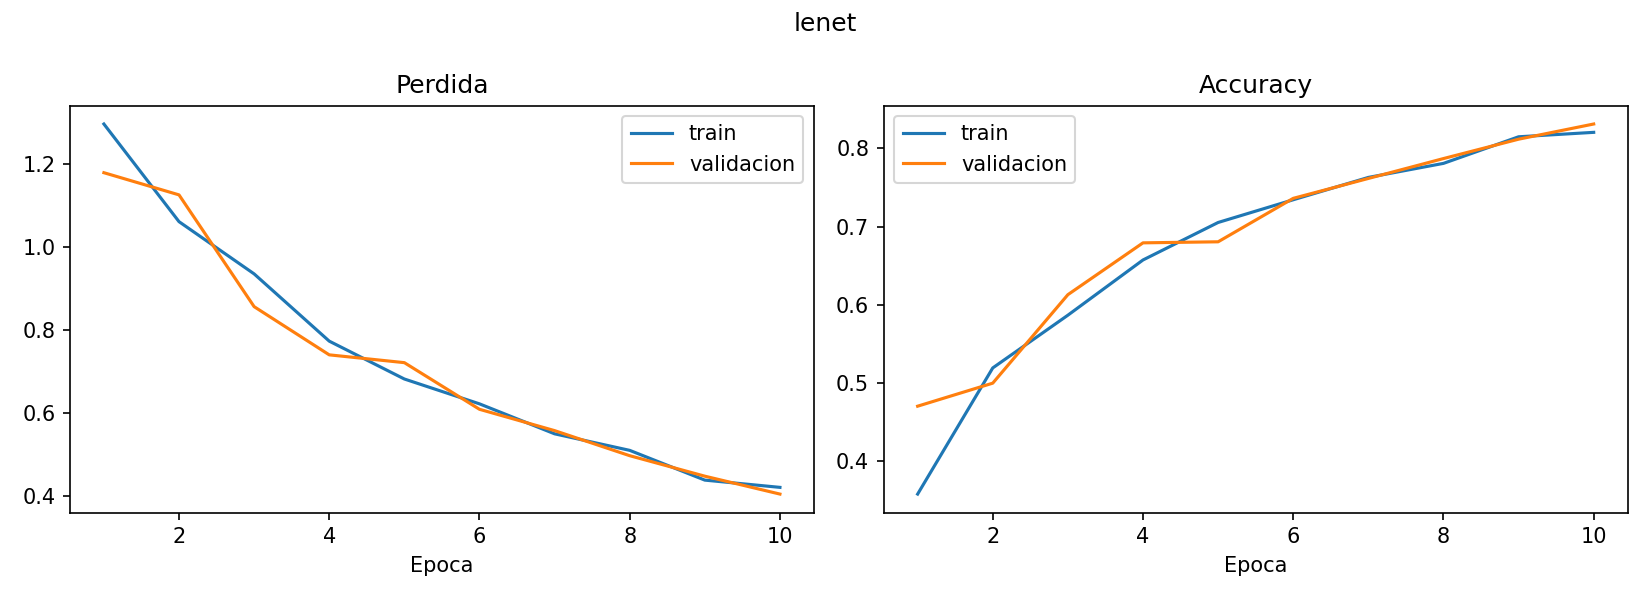

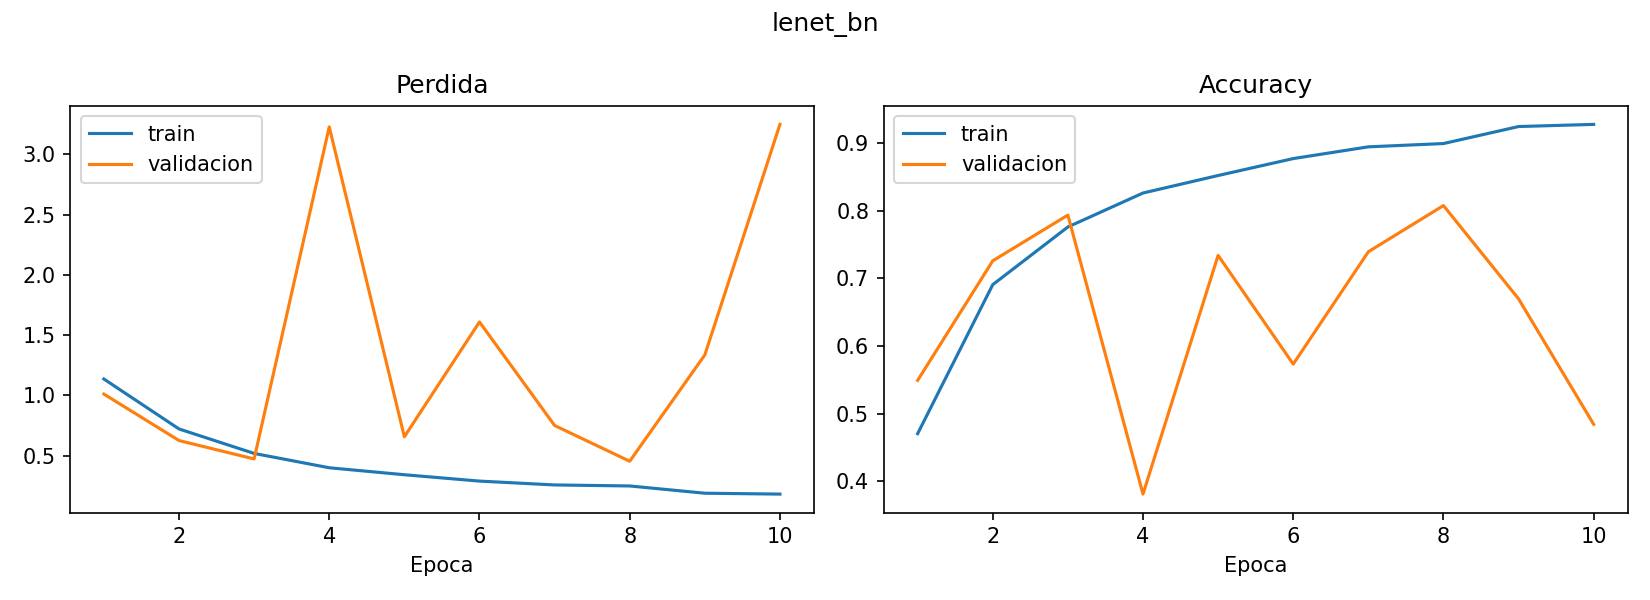

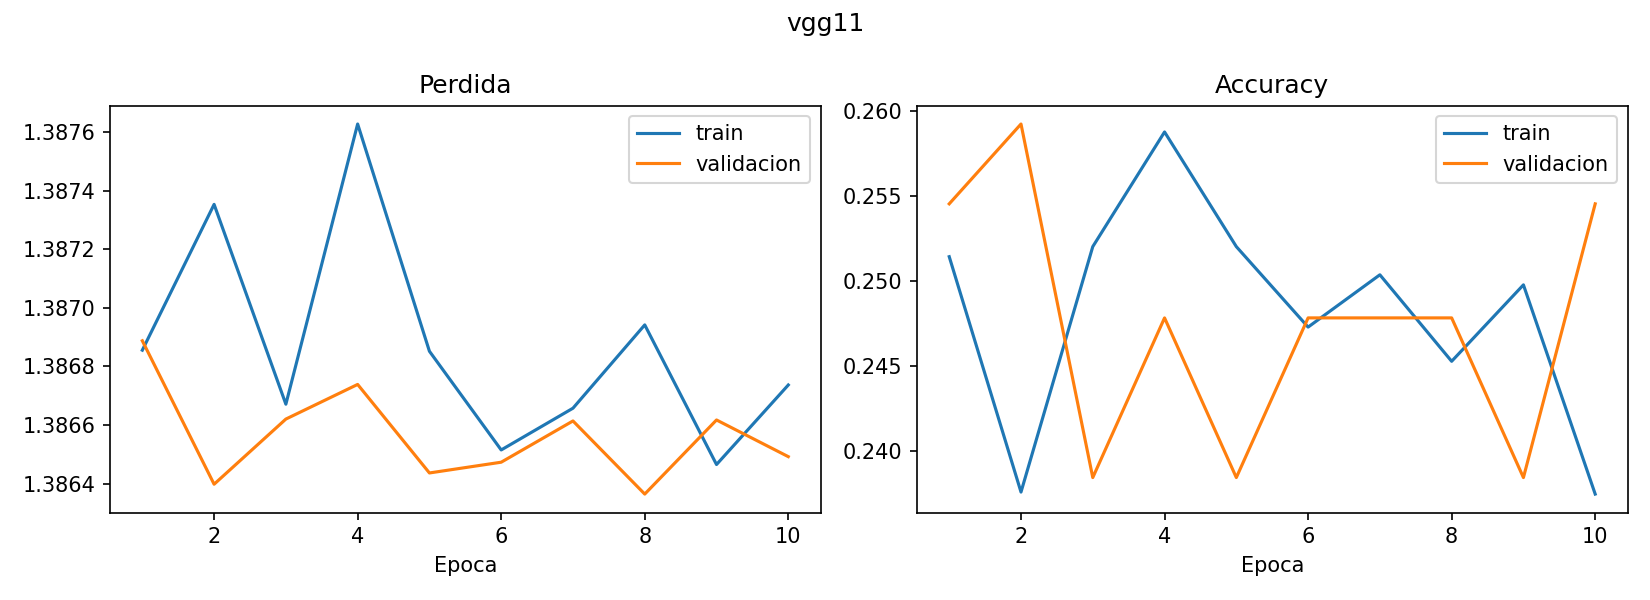

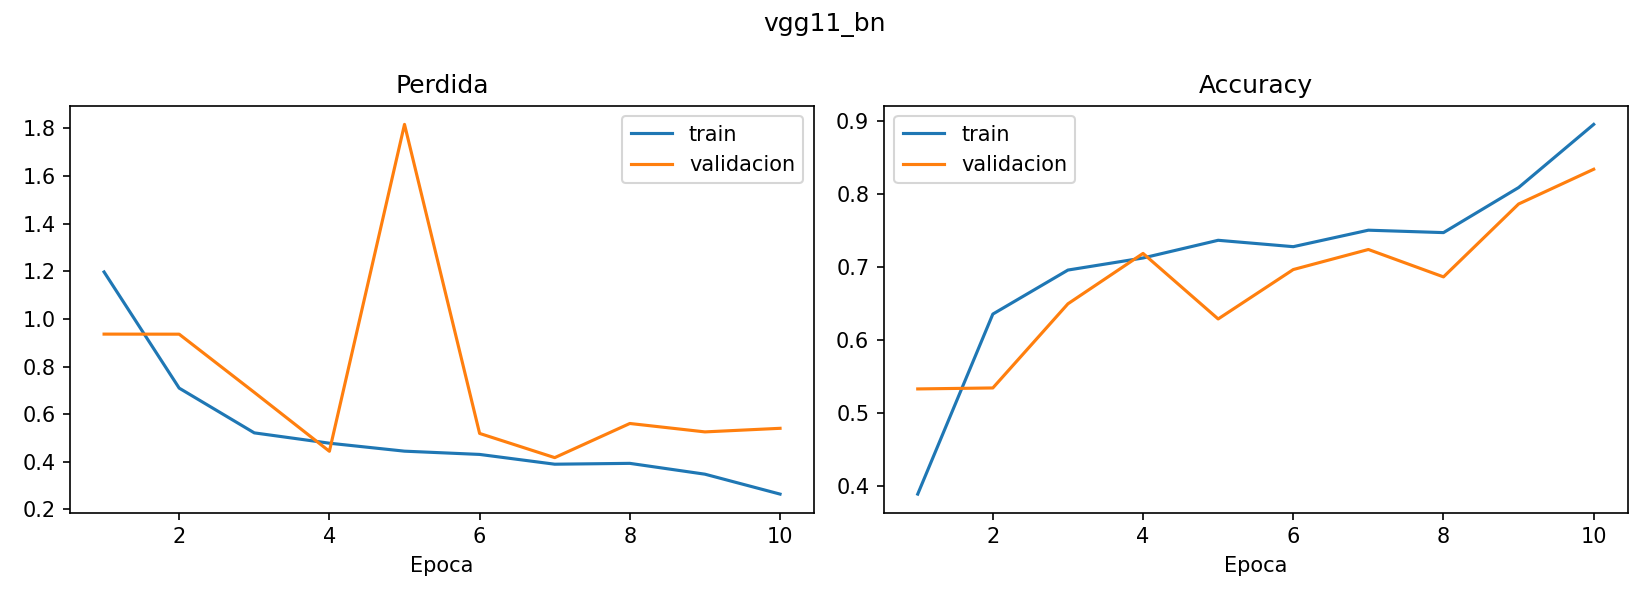

In [5]:
for model_name in task1_models:
    display(Image(filename=str(RESULTS_DIR / "figures" / f"{model_name}_curves.png")))

## Tarea 2: efecto de Batch Normalization

Experimento controlado: se usa la misma VGG-11 simplificada con y sin BN. La unica variable del primer par de corridas es Batch Normalization. Luego se repite con una tasa de aprendizaje mas alta para observar estabilidad. El analisis se apoya en Ioffe & Szegedy (2015), quienes introducen BN para reducir el *Internal Covariate Shift*.

In [6]:
EPOCHS_BN = 10

run_train(
    "--mode", "bn",
    "--epochs", EPOCHS_BN,
    "--batch-size", 64,
    "--lr", 0.001,
    "--high-lr", 0.01,
    *COMMON_ARGS,
)

c:\Users\magic\AppData\Local\Programs\Python\Python311\python.exe C:\Escritorio\PC\PC\dl-semana6-Pastor_Tomas\src\train.py --mode bn --epochs 10 --batch-size 64 --lr 0.001 --high-lr 0.01 --data-dir C:\Escritorio\PC\PC\dl-semana6-Pastor_Tomas\data\dataset --results-dir C:\Escritorio\PC\PC\dl-semana6-Pastor_Tomas\results --num-workers 0


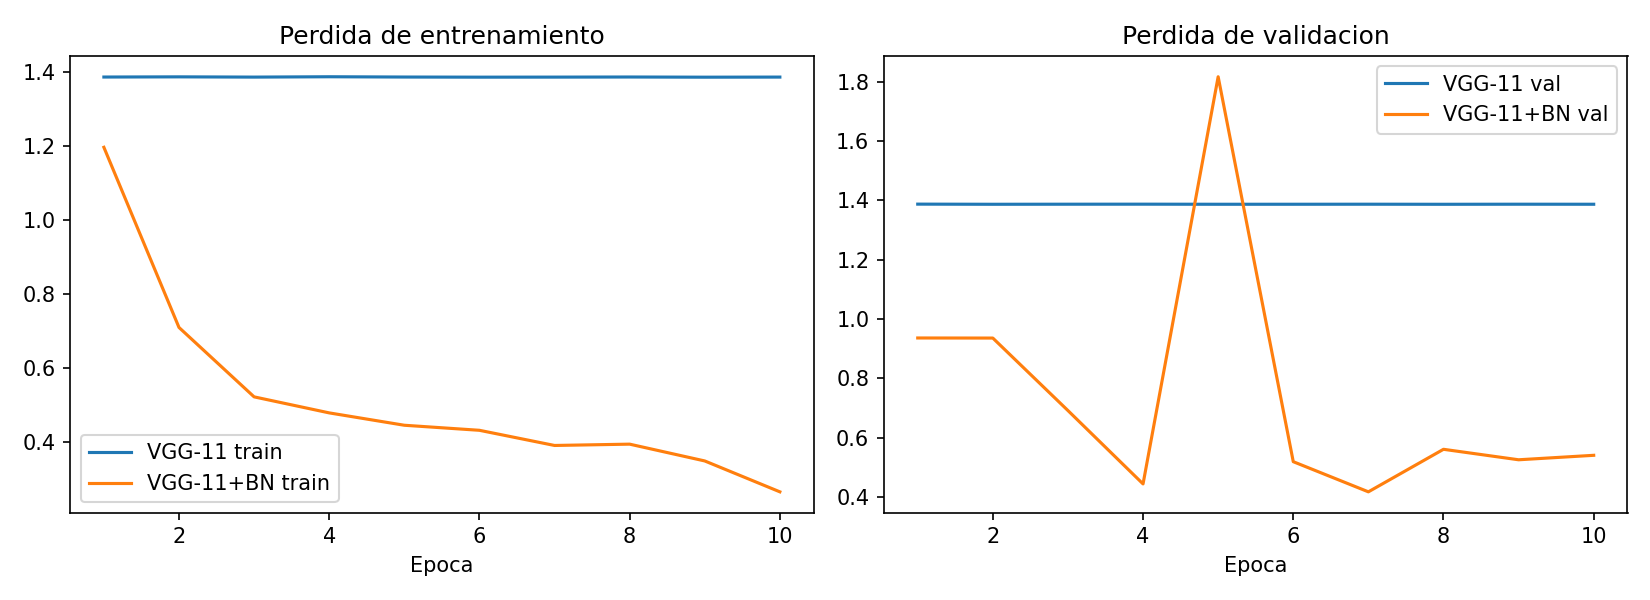

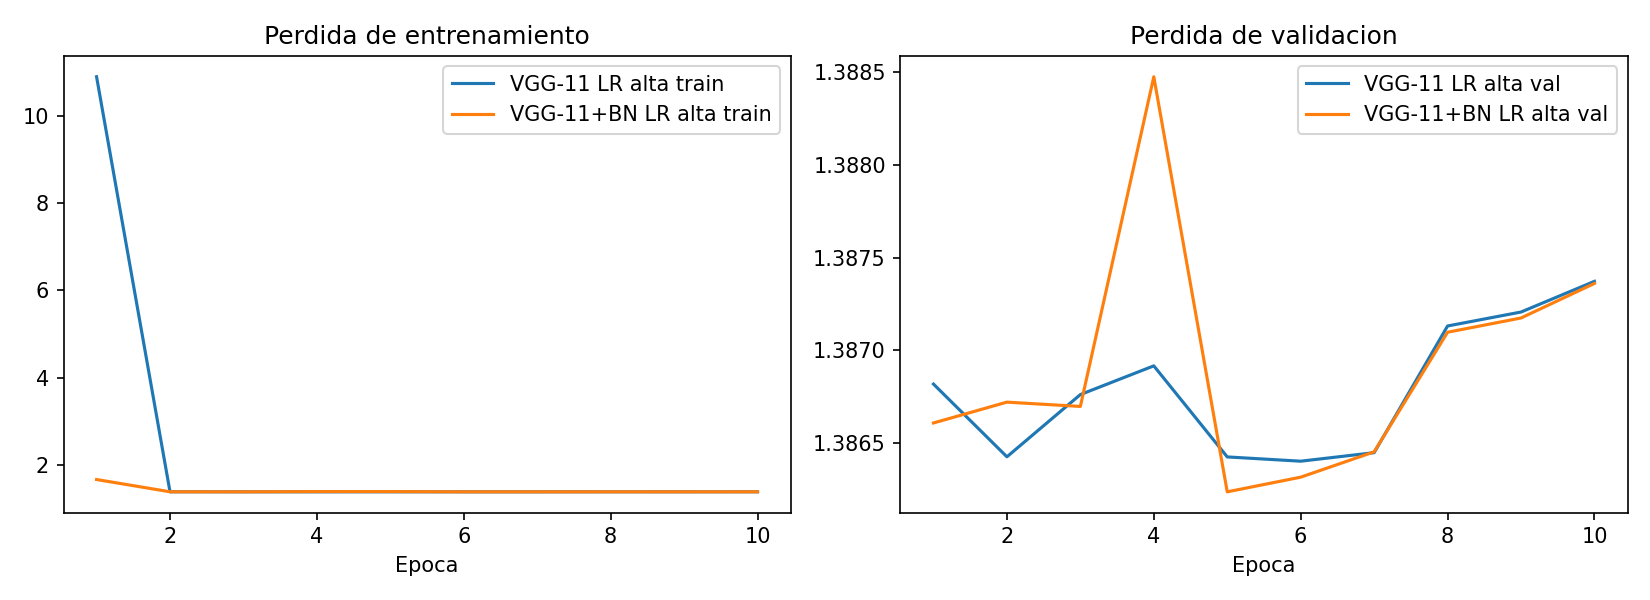

In [7]:
display(Image(filename=str(RESULTS_DIR / "figures" / "bn_loss_comparison.png")))
display(Image(filename=str(RESULTS_DIR / "figures" / "bn_high_lr_loss_comparison.png")))

In [8]:
summary = pd.read_csv(RESULTS_DIR / "tables" / "summary.csv")
bn_models = ["vgg11", "vgg11_bn", "vgg11_high_lr", "vgg11_bn_high_lr"]
summary[summary["model"].isin(bn_models)][columns].sort_values(["lr", "model"])

,model,parameters,mean_epoch_time_sec,best_val_accuracy,test_accuracy,epochs_to_80_val_accuracy,lr
2,vgg11,3095748,28.649656,0.259210,0.249296,NaN,0.001
3,vgg11_bn,3098500,27.476374,0.833891,0.716526,10.0,0.001
5,vgg11_bn_high_lr,3098500,26.358981,0.259210,0.249296,NaN,0.010
4,vgg11_high_lr,3095748,28.057240,0.259210,0.249296,NaN,0.010
